# Implementation of K-Means clustering MD trajectory data

In [73]:
import numpy as np
from ase.io.lammpsrun import read_lammps_dump_text
from ase.io.lammpsdata import read_lammps_data
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from gendyndiff.diffusion.data.batched_data import CustomCrystalDataset
from gendyndiff.common.data.collate import CustomCollate

In [74]:
dump_file_path = "/home/agore/GenDynDiff/datasets/SrTiO3/dump.NPT"
def read_lammps_types(dump_file_path):
    all_types = []  # Will hold types from all timesteps
    type_to_atomic_number = {1: 38, 2: 22, 3: 8}
    # Define mapping from atomic numbers to element symbols
    atomic_number_to_symbol = {38: "Sr", 22: "Ti", 8: "O"}

    with open(dump_file_path, 'r') as f:
        atoms_section = False
        atom_id_to_type = {}  # Reset for each timestep

        for line in f:
            line = line.strip()

            if line.startswith("ITEM: TIMESTEP") and atom_id_to_type:
                sorted_types = [atom_id_to_type[id] for id in sorted(atom_id_to_type.keys())]
                all_types.extend(sorted_types)
                atom_id_to_type = {}  # Reset for next timestep
                atoms_section = False

            # Check if we've reached the atoms section
            if line.startswith("ITEM: ATOMS"):
                atoms_section = True
                continue

            # Process atom data lines
            if atoms_section and line and not line.startswith("ITEM:"):
                columns = line.split()
                if len(columns) > 1:
                    atom_id = int(columns[0])
                    type_val = float(columns[1])
                    if type_val <= 3.0:
                        mapped_val = type_to_atomic_number.get(int(type_val))
                        if mapped_val is not None:
                            atom_id_to_type[atom_id] = mapped_val

        # Don't forget to process the last timestep
        if atom_id_to_type:
            sorted_types = [atom_id_to_type[id] for id in sorted(atom_id_to_type.keys())]
            all_types.extend(sorted_types)

    # Create a new array with element symbols
    all_symbols = [atomic_number_to_symbol[atomic_num] for atomic_num in all_types]

    return all_types, all_symbols

atom_types,atom_symbols = read_lammps_types(dump_file_path)
print(atom_types)
print(atom_symbols)


[38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8, 8, 38, 22, 8, 8,

In [75]:
dump_file_path = "/home/agore/GenDynDiff/datasets/SrTiO3/dump.NPT"
cfg_file_path = "/home/agore/GenDynDiff/datasets/SrTiO3/SrTiO3_555_5pO_5pSr.cfg"

# Load dataset using CustomCrystalDataset class
custom_collate = CustomCollate()
datasets = CustomCrystalDataset.from_dump_file(dump_file_path, cfg_file_path)

oxygen_trajectories = {}
n_clusters = 375
timestep=None
# Iterate through each timestep's dataset
for timestep_idx, dataset in enumerate(datasets):
    batched_data = custom_collate([dataset])

    num_atoms = batched_data.atoms.size(0)
    timestep = timestep_idx + 1

    for i in range(num_atoms):
        element = batched_data.elements[i].item()
        if element == 8:
            position = batched_data.positions[i].tolist()
            atom_id = f"{i}"
            if atom_id not in oxygen_trajectories:
                oxygen_trajectories[atom_id] = []

            oxygen_trajectories[atom_id].append(position)

print(timestep)
oxygen_traj_length = len(oxygen_trajectories)

101


In [76]:
all_positions = []
atom_to_positions = {}

for atom_id, positions in oxygen_trajectories.items():
    all_positions.extend(positions)
    atom_to_positions[atom_id] = np.array(positions)

all_positions = np.array(all_positions)
print(len(all_positions))

#T = np.random.rand(oxygen_traj_length,3,timestep)
#T_reshape = T.reshape(-1,3)
#T_reshape.shape



37875


(37875, 3)

In [3]:
import torch
T = torch.rand(oxygen_traj_length,3,timestep)
def set_labels(T,C):
    oxygen_traj,y,timesteps = T.shape

    L = T.reshape(-1,y)



NameError: name 'T' is not defined

In [100]:
i = 0
j = 0
T[i,j]

array([0.97878749, 0.08396333, 0.4382162 , 0.08339885, 0.82693654,
       0.70087807, 0.91085231, 0.07243265, 0.58874977, 0.53028717,
       0.94125299, 0.95666455, 0.19725782, 0.31028619, 0.16751963,
       0.95736197, 0.54310281, 0.75594529, 0.24107476, 0.33203359,
       0.43205115, 0.97794057, 0.46829824, 0.63832176, 0.48143501,
       0.8659599 , 0.66137544, 0.84328476, 0.54499498, 0.12468893,
       0.52474291, 0.89827591, 0.79638218, 0.24697178, 0.37022423,
       0.80475163, 0.01976531, 0.40705859, 0.51145317, 0.77557842,
       0.41197734, 0.97136058, 0.98927286, 0.02362709, 0.87203354,
       0.88779354, 0.84683086, 0.38050642, 0.17522558, 0.94261603,
       0.41137251, 0.33539898, 0.64279683, 0.39897772, 0.52413264,
       0.90706801, 0.73339035, 0.06991855, 0.63753781, 0.4778105 ,
       0.09423958, 0.10592808, 0.39069244, 0.26756024, 0.8090026 ,
       0.52950503, 0.68958595, 0.37330217, 0.40752805, 0.26917582,
       0.30839059, 0.66882739, 0.63171057, 0.48976544, 0.56661

In [101]:
kmeans = KMeans(n_clusters=n_clusters,n_init=10,random_state=42)
labels = kmeans.fit_predict(T[i,j])
cluster_centers = kmeans.cluster_centers_




ValueError: Expected 2D array, got 1D array instead:
array=[0.97878749 0.08396333 0.4382162  0.08339885 0.82693654 0.70087807
 0.91085231 0.07243265 0.58874977 0.53028717 0.94125299 0.95666455
 0.19725782 0.31028619 0.16751963 0.95736197 0.54310281 0.75594529
 0.24107476 0.33203359 0.43205115 0.97794057 0.46829824 0.63832176
 0.48143501 0.8659599  0.66137544 0.84328476 0.54499498 0.12468893
 0.52474291 0.89827591 0.79638218 0.24697178 0.37022423 0.80475163
 0.01976531 0.40705859 0.51145317 0.77557842 0.41197734 0.97136058
 0.98927286 0.02362709 0.87203354 0.88779354 0.84683086 0.38050642
 0.17522558 0.94261603 0.41137251 0.33539898 0.64279683 0.39897772
 0.52413264 0.90706801 0.73339035 0.06991855 0.63753781 0.4778105
 0.09423958 0.10592808 0.39069244 0.26756024 0.8090026  0.52950503
 0.68958595 0.37330217 0.40752805 0.26917582 0.30839059 0.66882739
 0.63171057 0.48976544 0.56661272 0.06708421 0.65979267 0.45012363
 0.14361157 0.07137442 0.3404623  0.3150256  0.19507265 0.16758142
 0.7

In [102]:
np.argmin(cluster_centers)

731

In [99]:
dir(kmeans.labels_)
print(kmeans.labels_)

[304 328 108 ... 357 333 238]


In [97]:
#actual k-means clustering algorithm




L = labels.reshape(oxygen_traj_length,timestep)
convergence_criterion = 0.0001
converged = False
iteration = 0
while not converged:
    iteration += 1

    # Step 1: Assign cluster labels based on nearest centers
    new_labels = np.zeros(T_reshape.shape[0], dtype=int)
    for i, point in enumerate(T_reshape):
        distances = np.linalg.norm(cluster_centers - point, axis=1)
        new_labels[i] = np.argmin(distances)

    # Step 2: Update cluster centers based on new assignments
    new_C = np.zeros_like(cluster_centers)
    for k in range(n_clusters):
        assigned_points = T_reshape[new_labels == k]
        if len(assigned_points) > 0:
            new_C[k] = np.mean(assigned_points, axis=0)

    # Check for convergence
    max_shift = np.max(np.linalg.norm(new_C - cluster_centers, axis=1))
    if max_shift < convergence_criterion:
        converged = True

    cluster_centers = new_C  # Update cluster centers
    L = new_labels.reshape(oxygen_traj_length, timestep)  # Update L matrix

    print(f"Iteration {iteration}: Max cluster shift = {max_shift:.4f} Å")
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
print(T.shape)

375
Iteration 1: Max cluster shift = 0.0019 Å
Iteration 2: Max cluster shift = 0.0013 Å
Iteration 3: Max cluster shift = 0.0009 Å
Iteration 4: Max cluster shift = 0.0009 Å
Iteration 5: Max cluster shift = 0.0015 Å
Iteration 6: Max cluster shift = 0.0011 Å
Iteration 7: Max cluster shift = 0.0007 Å
Iteration 8: Max cluster shift = 0.0000 Å
(375, 3, 101)


In [98]:
from collections import defaultdict

jumps = defaultdict(int)
dwell_times = defaultdict(list)

for atom_id, wlabels in labels.items():
    if len(wlabels) < 2:
        continue

    current_cluster = wlabels[0]
    dwell_start = 0

    for i in range(1, len(wlabels)):
        if wlabels[i] != current_cluster:
            # Record jump from one site to another
            jumps[(current_cluster, wlabels[i])] += 1

            # Record how long oxygen stayed at the site
            dwell_time = i - dwell_start
            dwell_times[current_cluster].append(dwell_time)

            # Update tracking
            current_cluster = wlabels[i]
            dwell_start = i

    dwell_time = len(wlabels) - dwell_start
    dwell_times[current_cluster].append(dwell_time)

AttributeError: 'numpy.ndarray' object has no attribute 'items'

In [79]:
print(f"Found {len(oxygen_trajectories)} oxygen atoms")
print(f"Identified {len(cluster_centers)} potential oxygen sites")
print(f"Recorded {len(jumps)} different jump types between sites")

print("\nMost common jumps:")
sorted_jumps = sorted(jumps.items(), key=lambda x: x[1], reverse=True)
for (from_site, to_site), count in sorted_jumps[:5]:
    print(f"From site {from_site} to site {to_site}: {count} jumps")

print("\nAverage dwell times at each site:")
for site, times in dwell_times.items():
    if times:
        avg_time = sum(times) / len(times)
        print(f"Site {site}: {avg_time:.2f} timesteps")

Found 375 oxygen atoms
Identified 375 potential oxygen sites
Recorded 176 different jump types between sites

Most common jumps:
From site 357 to site 204: 21 jumps
From site 204 to site 357: 20 jumps
From site 310 to site 85: 20 jumps
From site 85 to site 310: 20 jumps
From site 308 to site 193: 19 jumps

Average dwell times at each site:
Site 308: 3.26 timesteps
Site 193: 7.00 timesteps
Site 352: 4.60 timesteps
Site 155: 8.31 timesteps
Site 345: 3.56 timesteps
Site 252: 4.11 timesteps
Site 318: 3.11 timesteps
Site 78: 2.33 timesteps
Site 30: 7.95 timesteps
Site 323: 3.24 timesteps
Site 347: 3.44 timesteps
Site 341: 4.15 timesteps
Site 372: 3.38 timesteps
Site 282: 8.71 timesteps
Site 75: 101.00 timesteps
Site 59: 2.95 timesteps
Site 357: 2.48 timesteps
Site 349: 3.76 timesteps
Site 310: 2.71 timesteps
Site 255: 101.00 timesteps
Site 354: 3.93 timesteps
Site 60: 9.53 timesteps
Site 335: 3.14 timesteps
Site 106: 101.00 timesteps
Site 190: 101.00 timesteps
Site 10: 3.47 timesteps
Site 2

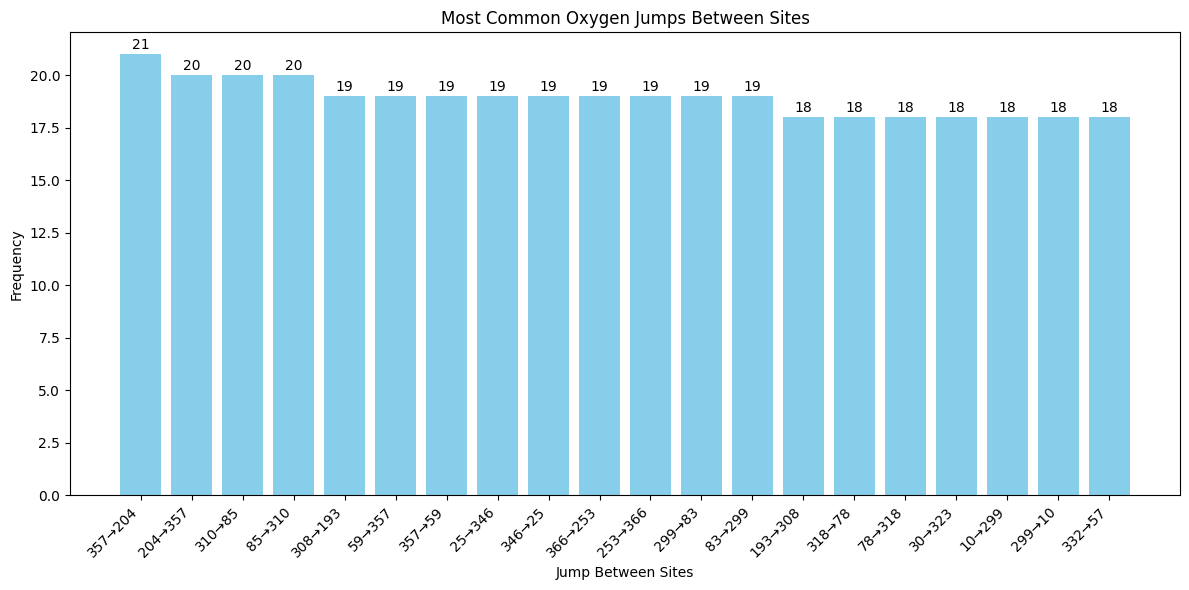

In [80]:
top_n = min(20, len(sorted_jumps))
top_jumps = sorted_jumps[:top_n]

# Create labels and values for the bar chart
jump_labels = [f"{jump[0][0]}→{jump[0][1]}" for jump in top_jumps]
jump_values = [jump[1] for jump in top_jumps]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(jump_labels)), jump_values, color='skyblue')
plt.xticks(range(len(jump_labels)), jump_labels, rotation=45, ha='right')
plt.xlabel('Jump Between Sites')
plt.ylabel('Frequency')
plt.title('Most Common Oxygen Jumps Between Sites')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('oxygen_jump_frequency.png', dpi=300)
plt.show()

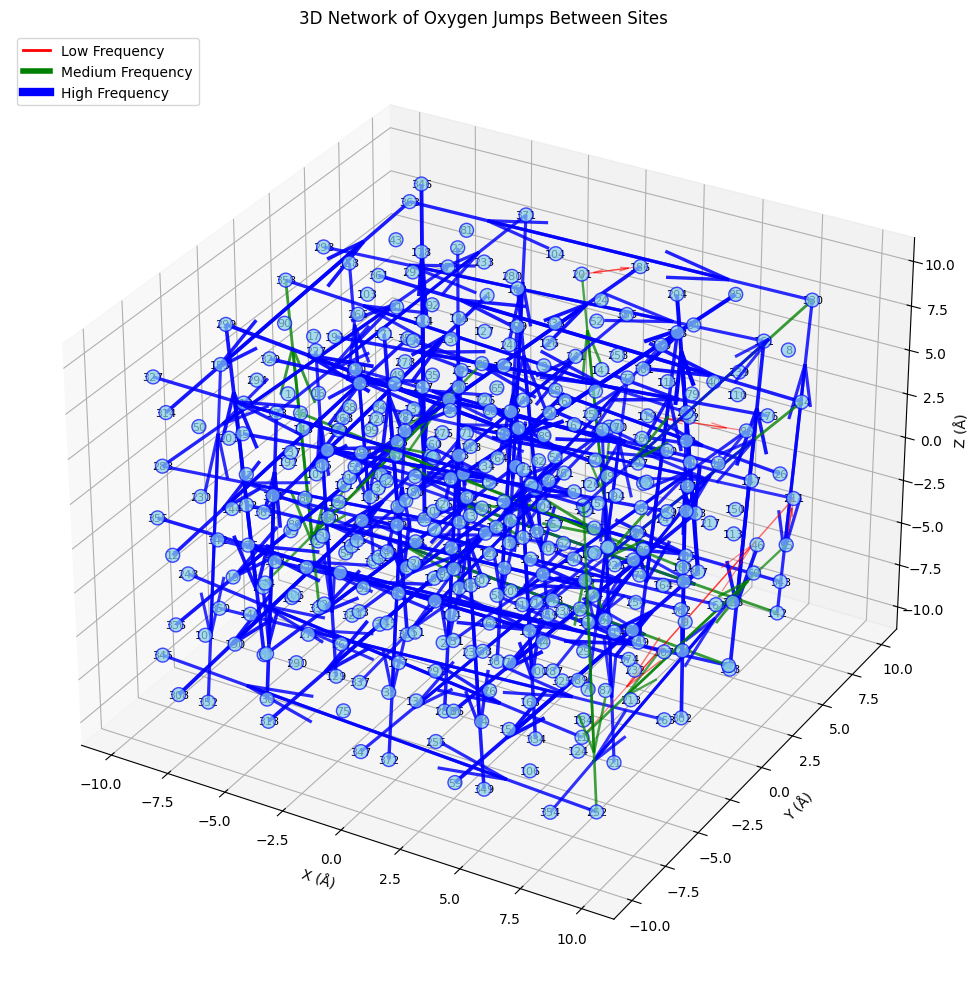

In [92]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import numpy as np

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot cluster centers (oxygen sites)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], cluster_centers[:, 2],
           s=100, c='skyblue', alpha=0.7, edgecolors='blue',
           marker='o', label='Oxygen Sites')

# Add site labels
for i, center in enumerate(cluster_centers):
    ax.text(center[0], center[1], center[2], str(i), fontsize=8,
            ha='center', va='center', color='black')

# Calculate maximum jump count for scaling
max_jump_count = max(count for (_, _), count in jumps.items()) if jumps else 1
threshold = max_jump_count * 0.1  # Only show jumps with at least 10% of max frequency

# Plot significant jumps as arrows with three different colors based on frequency
for (from_site, to_site), count in jumps.items():
    if count >= threshold:
        # Determine arrow properties based on jump frequency
        width = 0.5 + 2.5 * (count / max_jump_count)  # Adjust line width for visibility
        alpha = 0.4 + 0.6 * (count / max_jump_count)  # Adjust opacity

        # Assign color based on frequency tiers
        if count < max_jump_count * 0.33:
            color = 'red'    # Low frequency
        elif count < max_jump_count * 0.66:
            color = 'green'   # Medium frequency
        else:
            color = 'blue'  # High frequency

        from_pos = cluster_centers[from_site]
        to_pos = cluster_centers[to_site]

        # Define vector components for arrow direction
        dx, dy, dz = to_pos - from_pos

        # Plot arrow using quiver
        ax.quiver(from_pos[0], from_pos[1], from_pos[2],
                  dx*0.8, dy*0.8, dz*0.8,
                  arrow_length_ratio=0.2,
                  linewidth=width,
                  color=color,
                  alpha=alpha)

# Create custom legend elements for jump frequency tiers
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Low Frequency'),
    Line2D([0], [0], color='green', lw=4, label='Medium Frequency'),
    Line2D([0], [0], color='blue', lw=6, label='High Frequency')
]
ax.legend(handles=legend_elements, loc='upper left')

ax.set_xlabel('X (Å)')
ax.set_ylabel('Y (Å)')
ax.set_zlabel('Z (Å)')
ax.set_title('3D Network of Oxygen Jumps Between Sites')
plt.tight_layout()
plt.savefig('oxygen_jump_network_3d.png', dpi=300)
plt.show()